# Cyber Bullying Detection
<div style="">
  <img src="https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExaDR1aWJ3OWZhdXZ0MzdvNWx0NnZta3BvZTloY2lsNzBjaWc1MjFpbSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/4z7Z1WeRCksA4MH8Om/giphy.gif" width="300">
</div>

In [ ]:
pip install spacy

In [ ]:
! pip install textattack

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 42.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 31.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.7/445.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import re
import nltk
import spacy
import numpy as np
import pandas as pd
from tqdm import tqdm
from wordcloud import WordCloud
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import pad_sequences
from keras.utils import to_categorical
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Flatten, Dropout, Embedding, GlobalMaxPooling1D, Conv1D, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

from textattack.augmentation import WordNetAugmenter

from sklearn.metrics import classification_report, f1_score

nltk.download('punkt_tab')
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))
stop_words = [i for i in stop_words if i not in ['not','until','against','up', 'down', 'no', 'nor',"aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',
                                                "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't",
                                                 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't", "don't"]]

textattack: Updating TextAttack package dependencies.
textattack: Downloading NLTK required packages.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root

In [ ]:
df = pd.read_csv("/dataset.csv")
df=df.sample(frac=1)
df=df.head(10000)
df.head()

,Unnamed: 0,content,label
11267,11267,cool i got it up and working. It's taking a d...,0
9060,9060,WHOA WHOA WHOA. You might have to fight me for...,0
6209,6209,Gay!,1
7393,7393,Just had a big ass waffle breakfast and am cat...,1
4340,4340,I hate my life haha,1


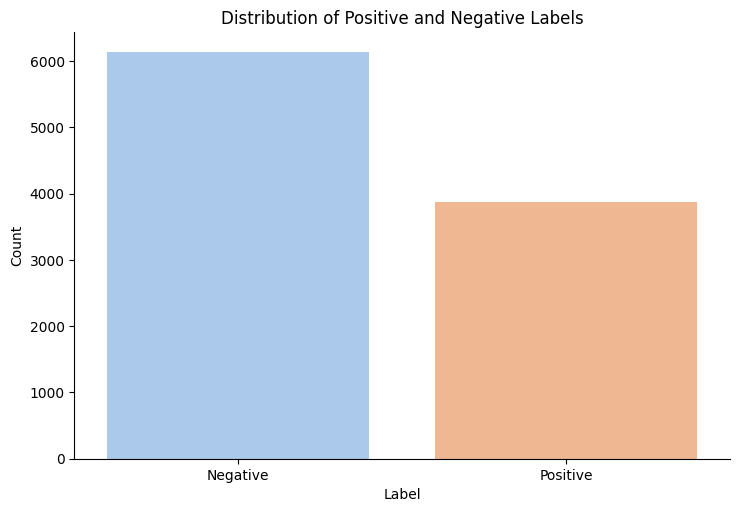

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df['label_name'] = df['label'].apply(lambda x: 'Positive' if x == 1 else 'Negative')
sns.catplot(x='label_name', kind='count', data=df, height=5, aspect=1.5, palette='pastel')
plt.title('Distribution of Positive and Negative Labels')
plt.xlabel('Label')
plt.ylabel('Count')

plt.show()

# FEATURE ENGINEERING

In [ ]:
def get_word_len(content):
    return len(content.split(' '))

def get_char_len(content):
    return len(content)

def preprocess_data(content):
    content = content.lower()
    content = re.sub(r"http\S+|www\S+|https\S+", '', content, flags=re.MULTILINE)  # Remove links
    content = re.sub(r'@\w+', '', content)  # Remove mentions
    content = re.sub(r'[^a-zA-Z\s]', '', content)  # Keep only letters and spaces
    tokens = [token.lemma_ for token in nlp(content) if token not in stop_words and len(token) > 1]
    return " ".join(tokens)

# Apply preprocessing
df["clean_content"] = df["content"].apply(preprocess_data)
df["content_word_len"] = df["clean_content"].apply(get_word_len)
df["content_char_len"] = df["clean_content"].apply(get_char_len)

# Normalization of numerical values
scaler = MinMaxScaler()
numerical_cols = ["content_word_len", "content_char_len"]
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display processed data
df.head()

,Unnamed: 0,content,label,label_name,clean_content,content_word_len,content_char_len
11267,11267,cool i got it up and working. It's taking a d...,0,Negative,cool get it up and work its take damn long tim...,0.102151,0.102362
9060,9060,WHOA WHOA WHOA. You might have to fight me for...,0,Negative,whoa whoa whoa you might have to fight I for i...,0.118280,0.121485
6209,6209,Gay!,1,Positive,gay,0.000000,0.003375
7393,7393,Just had a big ass waffle breakfast and am cat...,1,Positive,just have big ass waffle breakfast and be catc...,0.064516,0.070866
4340,4340,I hate my life haha,1,Positive,hate my life haha,0.016129,0.019123


In [ ]:
# Convert text data into numerical features using TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df["clean_content"])

# Define the target variable
y = df["label"]

# Use the Chi-Square test to select the top 1000 text features
chi2_selector = SelectKBest(chi2, k=1000)
X_text_selected = chi2_selector.fit_transform(X_text, y)
print(f"TF-IDF feature matrix shape: {X_text.shape} -> After selection: {X_text_selected.shape}")

# Convert normalized numerical features into a sparse matrix
X_numeric = df[numerical_cols].values
X_numeric_sparse = csr_matrix(X_numeric)
# Combine both feature sets horizontally
X_final = hstack([X_text_selected, X_numeric_sparse])

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


TF-IDF feature matrix shape: (10000, 5000) -> After selection: (10000, 1000)


**MLP**

---



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5974 - loss: 0.6758 - val_accuracy: 0.7120 - val_loss: 0.5860
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7314 - loss: 0.5482 - val_accuracy: 0.7700 - val_loss: 0.4813
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7891 - loss: 0.4545 - val_accuracy: 0.7965 - val_loss: 0.4511
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8035 - loss: 0.4217 - val_accuracy: 0.7970 - val_loss: 0.4385
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8181 - loss: 0.3994 - val_accuracy: 0.8040 - val_loss: 0.4261
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8277 - loss: 0.3801 - val_accuracy: 0.8100 - val_loss: 0.4242
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8301 - loss: 0.3621 - val_accuracy: 0.8055 - val_loss: 0.4245
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8389 - loss: 0.3473 - val_accuracy: 0.

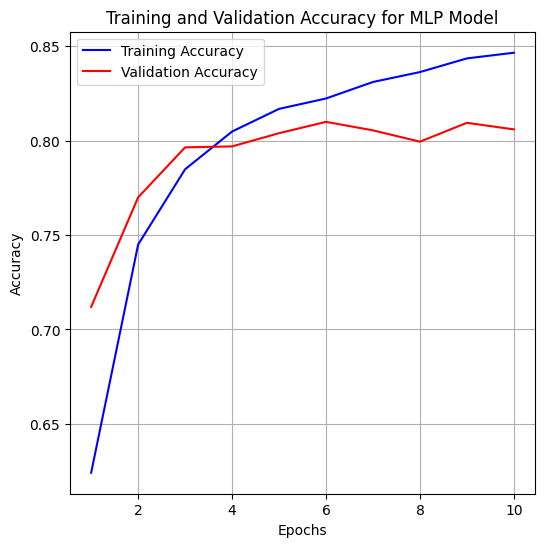

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85      1220
           1       0.80      0.67      0.73       780

    accuracy                           0.81      2000
   macro avg       0.80      0.78      0.79      2000
weighted avg       0.81      0.81      0.80      2000

F1 Score Overall: 0.7306


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, f1_score



y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Convert sparse matrix to dense format
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Define and compile MLP model
mlp_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(2, activation="sigmoid")  # Output layer with 2 units for binary classification
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train the model
history = mlp_model.fit(X_train_dense, y_train_categorical,
                        epochs=10, batch_size=64,
                        validation_data=(X_test_dense, y_test_categorical),
                        verbose=1)

from sklearn.metrics import classification_report
y_pred_mlp = mlp_model.predict(X_test_dense).argmax(axis=1)
print("MLP Model Performance:\n", classification_report(y_test, y_pred_mlp))


import matplotlib.pyplot as plt

# Extract training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for MLP Model')
plt.legend(loc='best')
plt.grid(True)
plt.show()


y_pred_probs = mlp_model.predict(X_test)

# Convert to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

# Generate classification report
report = classification_report(y_true, y_pred)
print("Classification Report:\n", report)


f1_mlp = f1_score(y_true, y_pred, average='binary')
print(f"F1 Score Overall: {f1_mlp:.4f}")

**Random Forest**

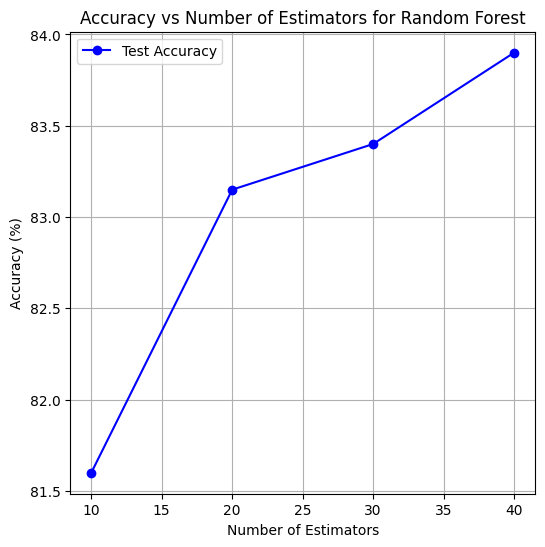

Accuracy: 83.90
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.87      1220
           1       0.84      0.72      0.78       780

    accuracy                           0.84      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.84      0.84      0.84      2000

F1 Score Overall: 0.8362


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd


# Text vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_content"])
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)


import matplotlib.pyplot as plt

# for different n_estimators
# as no epoch in rf so cant take that approach to get the graph
n_estimators = [10, 20, 30, 40]
accuracies = []

for n in n_estimators:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy * 100)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(n_estimators, accuracies, marker='o', linestyle='-', color='blue', label='Test Accuracy')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Number of Estimators for Random Forest')
plt.legend(loc='best')
plt.grid(True)

# Add text annotation
# plt.text(n_estimators[-1] - 20, accuracies[-1] - 1, 'Graph for Random Forest', fontsize=12, color='purple')

plt.show()



# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

f1_rf = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score Overall: {f1_rf:.4f}")


**LSTM**

---



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 198ms/step - accuracy: 0.6175 - loss: 0.6727 - val_accuracy: 0.6100 - val_loss: 0.6690
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.6165 - loss: 0.6675 - val_accuracy: 0.6100 - val_loss: 0.6688
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.6123 - loss: 0.6697 - val_accuracy: 0.6100 - val_loss: 0.6688
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 192ms/step - accuracy: 0.6042 - loss: 0.6737 - val_accuracy: 0.6100 - val_loss: 0.6690
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 204ms/step - accuracy: 0.6137 - loss: 0.6684 - val_accuracy: 0.6100 - val_loss: 0.6690
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.6179 - loss: 0.6667 - val_accuracy: 0.6100 - val_loss: 0.6688
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.6231 - loss: 0.6640 - val_accuracy: 0.6100 - val_loss: 0.6691
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 187ms/step - accuracy: 0.6076 - loss: 0

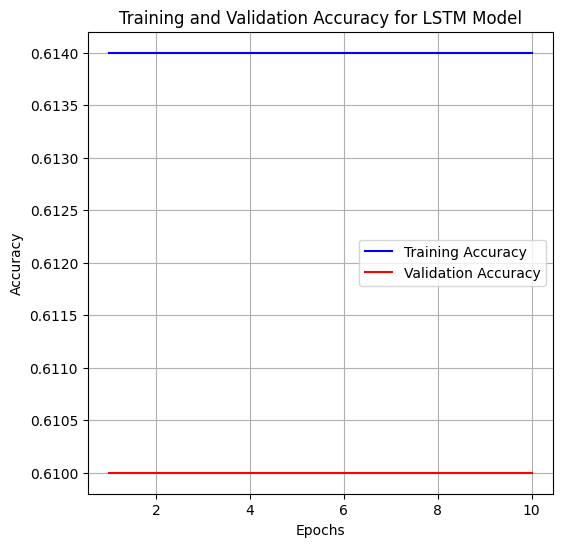

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6113 - loss: 0.6684
Test Accuracy: 61.00%
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76      1220
           1       0.00      0.00      0.00       780

    accuracy                           0.61      2000
   macro avg       0.30      0.50      0.38      2000
weighted avg       0.37      0.61      0.46      2000

F1 Score Overall: 0.4622


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# Tokenization
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_content"])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["clean_content"])
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Labels
labels = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

# Define LSTM model
model = Sequential([
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(32),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))


# Extract training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for LSTM Model')
plt.legend(loc='best')
plt.grid(True)

# Add text annotation

plt.show()


# Evaluate the model on the test set

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate weighted F1 score
f1_lstm = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score Overall: {f1_lstm:.4f}")

**GRU**

---



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 431ms/step - accuracy: 0.5985 - loss: 0.6773 - val_accuracy: 0.6200 - val_loss: 0.6661
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 410ms/step - accuracy: 0.5978 - loss: 0.6748 - val_accuracy: 0.6200 - val_loss: 0.6661
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 402ms/step - accuracy: 0.6137 - loss: 0.6698 - val_accuracy: 0.6200 - val_loss: 0.6648
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 52s 415ms/step - accuracy: 0.6159 - loss: 0.6665 - val_accuracy: 0.6200 - val_loss: 0.6642
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 407ms/step - accuracy: 0.6120 - loss: 0.6692 - val_accuracy: 0.6200 - val_loss: 0.6660
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 416ms/step - accuracy: 0.6124 - loss: 0.6689 - val_accuracy: 0.6200 - val_loss: 0.6643
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 405ms/step - accuracy: 0.6146 - loss: 0.6680 - val_accuracy: 0.6200 - val_loss: 0.6675
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 419ms/step - accuracy: 0.6185 - loss: 0

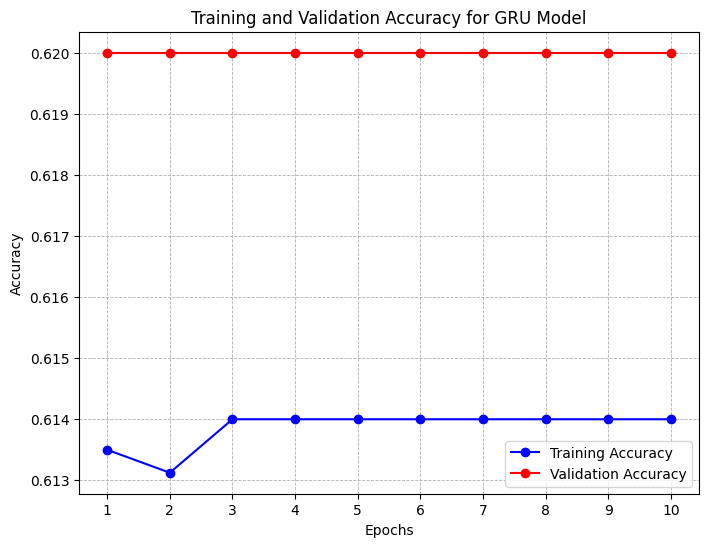

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# Tokenization
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_content"])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["clean_content"])
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Labels
labels = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

# Define GRU model
model = Sequential([
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    #Embedding(input_dim=5000, output_dim=128, input_length=100),
    GRU(128, return_sequences=True),
    Dropout(0.5),
    GRU(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")





y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate weighted F1 score
f1_gru = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1_gru:.4f}")
'''
import matplotlib.pyplot as plt

# Extract training and validation accuracy
train_acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')  # Blue with markers
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')  # Red with markers
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for GRU Model')
plt.legend(loc='best')
plt.grid(True, linestyle='--', linewidth=0.6)
plt.xticks(epochs)  # Ensure all epochs are visible
plt.show()

'''

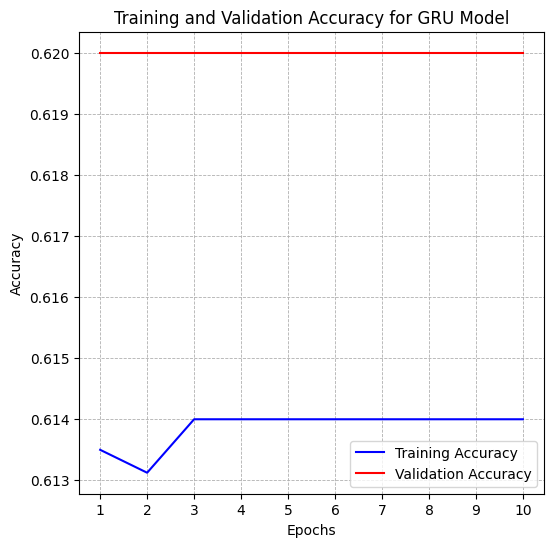

In [ ]:
'''import matplotlib.pyplot as plt

# Extract accuracy values
train_acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
epochs = range(1, len(train_acc) + 1)

# Create the plot
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')  # Blue solid line
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')  # Red solid line
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for GRU Model')
plt.legend(loc='best')
plt.grid(True, linestyle='--', linewidth=0.6)
plt.xticks(epochs)  # Ensure all epochs are shown
plt.show()
'''

**CONVOLUTION**

---



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6158 - loss: 0.6661 - val_accuracy: 0.7140 - val_loss: 0.5556
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.7581 - loss: 0.4983 - val_accuracy: 0.7690 - val_loss: 0.4802
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.8799 - loss: 0.3132 - val_accuracy: 0.7985 - val_loss: 0.4818
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9458 - loss: 0.1750 - val_accuracy: 0.7920 - val_loss: 0.5509
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9680 - loss: 0.1063 - val_accuracy: 0.8135 - val_loss: 0.6003
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9800 - loss: 0.0619 - val_accuracy: 0.8025 - val_loss: 0.6941
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.9885 - loss: 0.0405 - val_accuracy: 0.8205 - val_loss: 0.7463
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.9888 - loss: 0.0400 - va

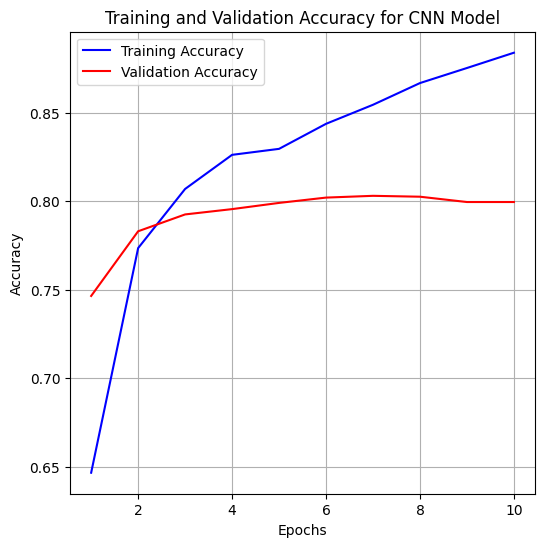

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1233
           1       0.72      0.80      0.76       767

    accuracy                           0.81      2000
   macro avg       0.79      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000

Weighted F1 Score: 0.8070


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer  # converting words into numeric tokens
from tensorflow.keras.preprocessing.sequence import pad_sequences #Ensures all sequences have the same length by adding padding
from tensorflow.keras.models import Sequential   #A linear stack of layers for building the model
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input, SpatialDropout1D  #Converts words into dense vector representations
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# Tokenization
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_content"])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["clean_content"])
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Labels
labels = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

# Build Convolutional model
model = Sequential([
    Input(shape=(100,)),
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.2),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")



import matplotlib.pyplot as plt

# Extract training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN Model')
plt.legend(loc='best')
plt.grid(True)
plt.show()





y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate Weighted F1 Score
f1_conv = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1_conv:.4f}")







**BIDIRECTIONAL+LSTM**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 380ms/step - accuracy: 0.6174 - loss: 0.6622 - val_accuracy: 0.7219 - val_loss: 0.5652
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 360ms/step - accuracy: 0.7961 - loss: 0.4727 - val_accuracy: 0.7269 - val_loss: 0.5521
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 398ms/step - accuracy: 0.8687 - loss: 0.3331 - val_accuracy: 0.7506 - val_loss: 0.5482
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 375ms/step - accuracy: 0.9169 - loss: 0.2292 - val_accuracy: 0.7594 - val_loss: 0.6845
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.9466 - loss: 0.1678 - val_accuracy: 0.7356 - val_loss: 0.7994
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 375ms/step - accuracy: 0.9557 - loss: 0.1349 - val_accuracy: 0.7525 - val_loss: 0.9148
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 376ms/step - accuracy: 0.9693 - loss: 0.0927 - val_accuracy: 0.7362 - val_loss: 0.9780
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.9693 - loss: 0

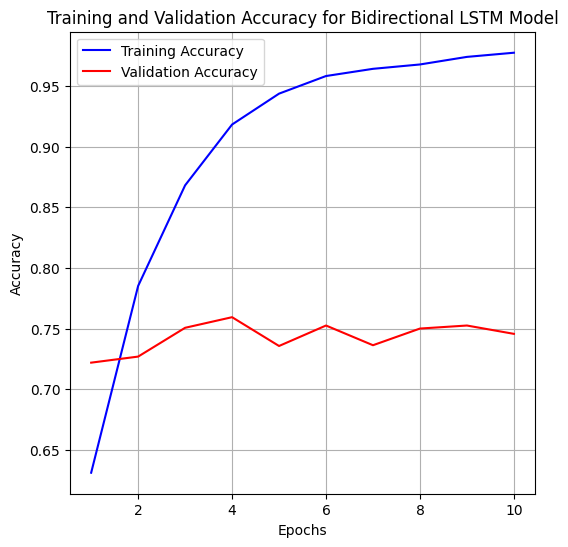

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.78      0.81      1233
           1       0.68      0.76      0.72       767

    accuracy                           0.77      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.78      0.77      0.77      2000

Weighted F1 Score: 0.7710


In [ ]:
import tensorflow as tf
import re
import nltk
import spacy
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from tqdm import tqdm

# Load Spacy model and stopwords
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

# Function to preprocess text
def preprocess_data(content):
    content = content.lower()
    content = re.sub(r"http\S+|www\S+|https\S+", '', content)  # Remove links
    content = re.sub(r'@\w+', '', content)  # Remove mentions
    content = re.sub(r'[^\w\s#]', '', content)  # Remove special characters
    tokens = [token.lemma_ for token in nlp(content) if token.text not in stop_words and len(token.text) > 1]
    return " ".join(tokens)

# Apply preprocessing
df['clean_content'] = df['content'].apply(preprocess_data)

# Tokenization and padding
max_words = 10000
max_len = 100
embedding_dim = 125
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_content'])

X = tokenizer.texts_to_sequences(df['clean_content'])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = df['label'].values

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Bidirectional LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
epochs = 10
batch_size = 64
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")



import matplotlib.pyplot as plt

# Extract training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Bidirectional LSTM Model')
plt.legend(loc='best')
plt.grid(True)

plt.show()





y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate Weighted F1 Score
f1_bi_lstm = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1_bi_lstm:.4f}")







**Bidirection+GRU**

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 215ms/step - accuracy: 0.6331 - loss: 0.6506 - val_accuracy: 0.7285 - val_loss: 0.5337
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.8140 - loss: 0.4246 - val_accuracy: 0.7580 - val_loss: 0.5116
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 198ms/step - accuracy: 0.8874 - loss: 0.2856 - val_accuracy: 0.7870 - val_loss: 0.5447
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.9382 - loss: 0.1718 - val_accuracy: 0.7495 - val_loss: 0.6065
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.9624 - loss: 0.1103 - val_accuracy: 0.7955 - val_loss: 0.7552
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 198ms/step - accuracy: 0.9774 - loss: 0.0751 - val_accuracy: 0.7735 - val_loss: 1.0273
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 212ms/step - accuracy: 0.9790 - loss: 0.0635 - val_accuracy: 0.7720 - val_loss: 0.9294
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 208ms/step - accuracy: 0.9844 - loss: 0

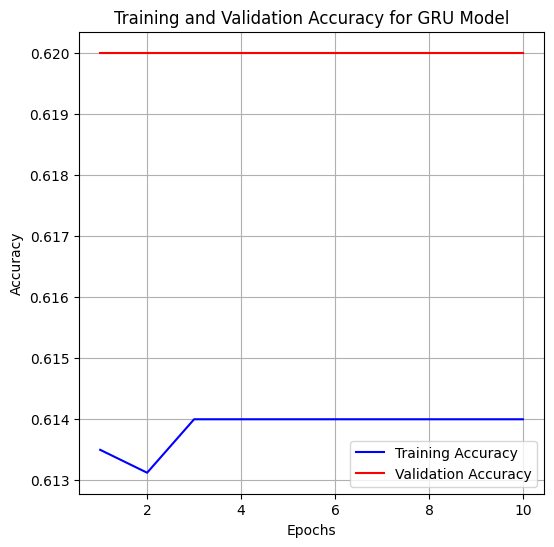

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      1240
           1       0.71      0.74      0.73       760

    accuracy                           0.79      2000
   macro avg       0.77      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000

Weighted F1 Score: 0.7887


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming df['clean_content'] is already preprocessed
# Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_content'])
X = tokenizer.texts_to_sequences(df['clean_content'])
X = pad_sequences(X, maxlen=50)

# Labels
y = df['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Architecture
model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=128, input_length=50),
    Bidirectional(GRU(64, return_sequences=True)),
    Bidirectional(GRU(32)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64)

# Predict and Calculate Accuracy
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")




import matplotlib.pyplot as plt

# Extract training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plotting
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Bidirectional GRU Model')
plt.legend(loc='best')
plt.grid(True)

plt.show()




y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Calculate Weighted F1 Score
f1_bi_gru = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1_bi_gru:.4f}")



# Improvement to Increase the Accuracy

**Introducing the Word Augmentation and Bag of Words**

In [ ]:
# Initialize the WordNet Augmenter
augmenter = WordNetAugmenter()

# Perform data augmentation by generating one augmented sentence per input
df_augmented = pd.DataFrame({
    'clean_content': df['clean_content'].apply(lambda x: augmenter.augment(x)[0] if len(augmenter.augment(x)) > 0 else x),
    'label': df['label']
})

# Combine original and augmented data
df_combined = pd.concat([df, df_augmented])

# Shuffle
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

# Split dataset
X_train_texts, X_test_texts, y_train, y_test = train_test_split(df_combined['clean_content'], df_combined['label'], test_size=0.2, random_state=42)

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts)
X_test_tfidf = tfidf_vectorizer.transform(X_test_texts)

# BoW (Count Vectorizer)
bow_vectorizer = CountVectorizer(ngram_range=(1, 1))
X_train_bow = bow_vectorizer.fit_transform(X_train_texts)
X_test_bow = bow_vectorizer.transform(X_test_texts)

# Combine both feature sets (TF-IDF + BoW)
X_train_combined = np.hstack((X_train_tfidf.toarray(), X_train_bow.toarray()))
X_test_combined = np.hstack((X_test_tfidf.toarray(), X_test_bow.toarray()))


y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**MLP**

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6566 - loss: 0.6152 - val_accuracy: 0.8328 - val_loss: 0.3880
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9009 - loss: 0.2565 - val_accuracy: 0.9025 - val_loss: 0.2535
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9665 - loss: 0.1013 - val_accuracy: 0.9243 - val_loss: 0.2126
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9827 - loss: 0.0549 - val_accuracy: 0.9283 - val_loss: 0.2232
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9857 - loss: 0.0420 - val_accuracy: 0.9335 - val_loss: 0.2207
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9360 - loss: 0.2170
Test Accuracy: 93.35%


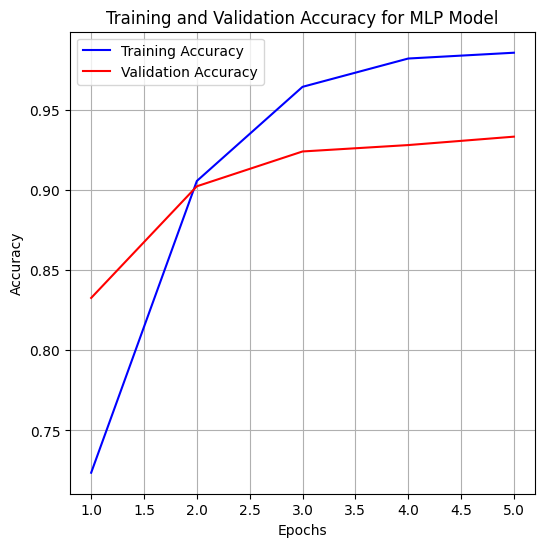

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.94      2375
           1       0.91      0.93      0.92      1625

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000

F1 Score Overall: 0.9336


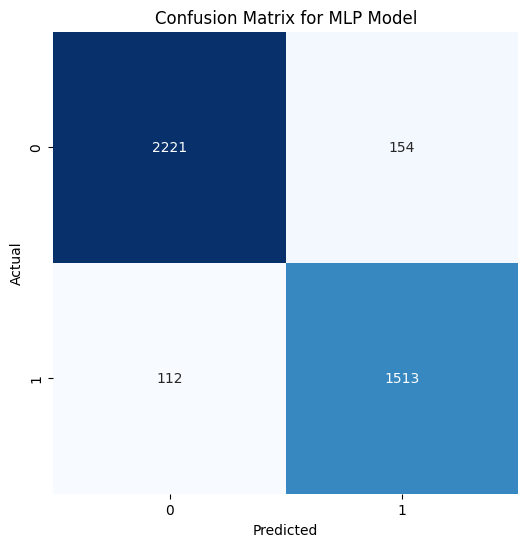

In [ ]:
mlp_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_combined.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(2, activation="sigmoid")
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

# Train the model
history = mlp_model.fit(X_train_combined, y_train_categorical,
                        epochs=5, batch_size=64,
                        validation_data=(X_test_combined, y_test_categorical),
                        verbose=1)



test_loss, test_accuracy = mlp_model.evaluate(X_test_combined, y_test_categorical, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)


plt.figure(figsize=(6, 6))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for MLP Model')
plt.legend(loc='best')
plt.grid(True)
plt.show()



y_pred_probs = mlp_model.predict(X_test_combined)

# Convert to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)


# Generate classification report
report = classification_report(y_true, y_pred)
print("Classification Report:\n", report)


f1_mlp_aug = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score Overall: {f1_mlp_aug:.4f}")


from sklearn.metrics import confusion_matrix
import pickle

# Generate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP Model')
plt.show()


# with open('/content/drive/MyDrive/mlp_model.pkl', 'wb') as f:
#     pickle.dump(mlp_model, f)

**Random Forest**

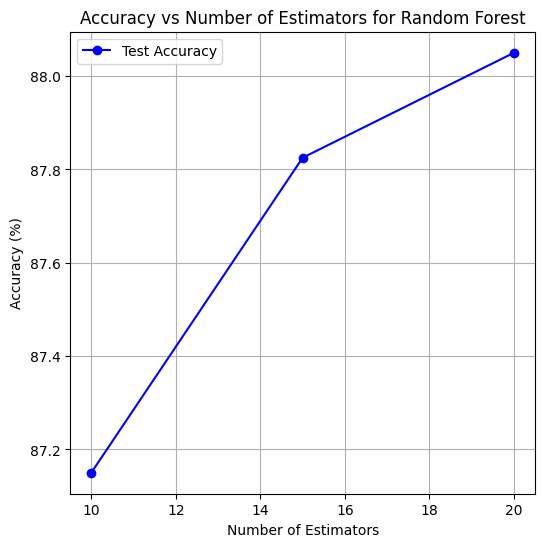

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      2448
           1       0.87      0.82      0.84      1552

    accuracy                           0.88      4000
   macro avg       0.88      0.87      0.87      4000
weighted avg       0.88      0.88      0.88      4000

F1 Score: 0.8798


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10)
rf_model.fit(X_train_combined, y_train)

y_pred = rf_model.predict(X_test_combined)


# Evaluation Graph
# for different n_estimators
# as no epoch in rf so cant take that approach to get the graph
n_estimators = [10,15, 20]
accuracies = []
from sklearn.metrics import accuracy_score

for n in n_estimators:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train_combined, y_train)
    y_pred = rf_model.predict(X_test_combined)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy * 100)

# Plot the accuracy
plt.figure(figsize=(6, 6))
plt.plot(n_estimators, accuracies, marker='o', linestyle='-', color='blue', label='Test Accuracy')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Number of Estimators for Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate F1 Score
f1_rf_aug = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1_rf_aug:.4f}")

# F1-Score Compare

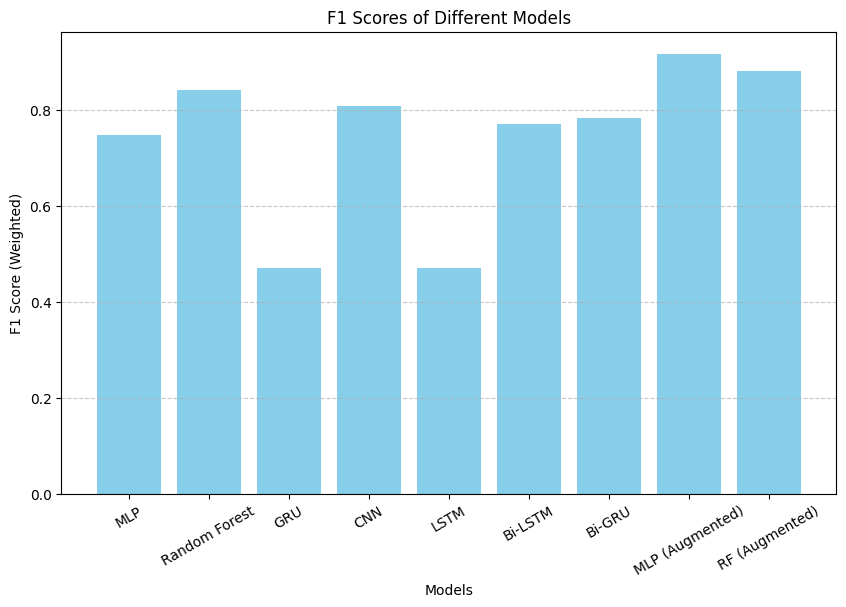

In [ ]:
f1_scores = {
    "MLP": f1_mlp,
    "Random Forest": f1_rf,
    "GRU": f1_gru,
    "CNN": f1_conv,
    "LSTM": f1_lstm,
    "Bi-LSTM": f1_bi_lstm,
    "Bi-GRU": f1_bi_gru,
    "MLP (Augmented)": f1_mlp_aug,
    "RF (Augmented)": f1_rf_aug,
}

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue')
plt.xlabel('Models')
plt.ylabel('F1 Score (Weighted)')
plt.title('F1 Scores of Different Models')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [1]:
!pip install streamlit pyngrok


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 812.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 1.6 MB/s eta 0:00:00


In [6]:
%%writefile app.py

import streamlit as st
import joblib
from cyber_detect_final.ipynb import preprocess_text, model  # adjust if needed

st.set_page_config(page_title="Cyberbullying Detector")

st.title("💬 Cyberbullying Comment Detection")
st.write("Enter a comment to detect whether it's bullying or not.")

user_input = st.text_area("Comment", height=150, placeholder="Type or paste a comment here...")

if st.button("Detect"):
    if not user_input.strip():
        st.warning("Please enter a comment first.")
    else:
        cleaned = preprocess_text(user_input)
        prediction = model.predict([cleaned])[0]

        if prediction == 1:
            st.error("🚨 This comment may contain **cyberbullying** content.")
        else:
            st.success("✅ This comment is **not** detected as cyberbullying.")


Overwriting app.py


In [8]:
!ngrok config add-authtoken 2w5gySxGA5gyOOpfLVMonRvUpsz_89e1WKcEmAiQsfgUPseqN


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [9]:
from pyngrok import ngrok

# Kill any previous streamlit processes
!pkill streamlit

# Run the Streamlit app
!streamlit run app.py &>/content/logs.txt &

# Open a tunnel on the default port 8501
url = ngrok.connect(8501)
print(f"🌐 Your app is live at: {url}")


🌐 Your app is live at: NgrokTunnel: "https://5629-34-32-160-0.ngrok-free.app" -> "http://localhost:8501"
